# 2025 DL Lab3: Semi-Supervised Flower Classfication

## Semi-supervised Flower Classfication

In this approach, you have a dataset that includes both labeled and unlabeled examples.

The goal is to use the labeled data to train the model while also leveraging the unlabeled
data to improve the model's performance.

In this assignment, you’ll explore a self-training mechanism for this task.


**Please note that you’re not allowed to use pre-constructed models or pre-trained weights.**

## Kaggle Competition
Kaggle is an online community of data scientists and machine learning practitioners. Kaggle allows users to find and publish datasets, explore and build models in a web-based data-science environment, work with other data scientists and machine learning engineers, and enter competitions to solve data science challenges.

This assignment use kaggle to calculate your grade.  
Please use this [**LINK**](https://www.kaggle.com/t/a611e0096e5943cc99a1c0545be28c3c) to join the competition.


##  Versions of used packages

We will check PyTorch version to make sure everything work properly.

In [49]:
import sys
import torch
import torchvision
print('python', sys.version.split('\n')[0])
print('torch', torch.__version__)
print('torchvision', torchvision.__version__)

python 3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 16:37:03) [MSC v.1929 64 bit (AMD64)]
torch 2.8.0+cu129
torchvision 0.23.0+cu129


# Prepare Data

We use [Flowers Recognition](https://www.kaggle.com/alxmamaev/flowers-recognition) dataset.
This is collected by Alexander Mamaev.

**Abstrct**  

We clean the dataset,this dataset contains 4262 flower images.   
**IMPORTANT: you CANNOT use any extra images.**

The data collection is grabed from the data flicr, google images, yandex images.
You can use this datastet to recognize plants from the photo.

The pictures are divided into five classes:
+ daisy
+ tulip
+ rose
+ sunflower
+ dandelion

For each class there are about 800 photos. Photos are not high resolution, about 320x240 pixels. Photos are not reduced to a single size, they have different proportions!

## Unzip Data

Unzip `Lab3_data_flower_2025.zip`, there are 3 folders.

- `train/`: 6 subfolders total.
   - `daisy/`, `dandelion/`, `rose/`, `sunflower/`, `tulip/`: labeled training images.
   - `unlabel/`: unlabeled training images.
contains 6 folders for 5 categories of flowers. Images of flowers inside them.
- `val/`: contains 5 folders for the same 5 classes. Labeled validation images for each class.
- `test/`: unclassified images of testing set.
---

There are **1200 images in labeled training set.**  

There are **1202 images in unlabeled training set.**

There are **678 images in validation set.**

There are **1215 images in test set.**  


## Loading the dataset

In [50]:
data_folder = 'Lab3_data_flower_2025'

### Custom dataset

Build a classs inherit `torch.utils.data.Dataset`.  
Implement `__init__`, `__getitem__` and `__len__` 3 functions.  

Some operations could be there: setting location of dataset, the method of reading data, label of dataset or transform of dataset.

See [torch.utils.data.Dataset](https://pytorch.org/docs/stable/data.html#torch.utils.data.Dataset) for more details

In [51]:
import csv
import os.path as osp
from pathlib import Path
from PIL import Image
import torch
from torch.utils.data import DataLoader, Dataset, TensorDataset
import pandas as pd

CLASS_NAMES = ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']
CLASS_TO_IDX = {c:i for i, c in enumerate(CLASS_NAMES)}
VALID_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.webp'}

class FlowerData(Dataset):
    def __init__(self, root, split='train', mode='train', transform=None, use_unlabel=False):
        self.root = Path(root)
        self.split = split
        self.mode = mode
        self.transform = transform
        self.use_unlabel = use_unlabel

        self.paths = []
        self.labels = []
        self.rel_paths = []

        # Load data from unified CSV files
        if split == 'train' and use_unlabel:
            csv_file = self.root / 'unlabeled_train.csv'
        elif split == 'train':
            csv_file = self.root / 'train.csv'
        elif split == 'val':
            csv_file = self.root / 'val.csv'
        else:  # test
            csv_file = self.root / 'test.csv'

        # Read CSV file using pandas for better handling
        df = pd.read_csv(csv_file)

        for _, row in df.iterrows():
            file_path = self.root / row['file_name']
            self.paths.append(file_path)
            self.rel_paths.append(row['file_name'])

            # Handle labels
            if split == 'test' or (split == 'train' and use_unlabel):
                # No labels for test or unlabeled data
                pass
            else:
                # For labeled data
                if pd.isna(row['groundtruth']) or row['groundtruth'] == '':
                    self.labels.append(-1)  # Invalid label for debugging
                else:
                    self.labels.append(CLASS_TO_IDX[row['groundtruth']])

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, index):
        img_path = self.paths[index]
        img = Image.open(img_path).convert('RGB')
        if self.transform is not None:
            img = self.transform(img)

        if self.mode == 'test' or (self.split == 'train' and self.use_unlabel):
            return img
        label = int(self.labels[index])
        return img, torch.tensor(label, dtype=torch.long)

### Data augmentation

Data augmentation are techniques used to increase the amount of data by adding slightly modified copies of already existing data or newly created synthetic data from existing data.

PyTorch use `torchvision.transforms` to do data augmentation.
[You can see all function here.](https://docs.pytorch.org/vision/main/transforms.html)  

There are some operations may not be necessary for predict, so we should write one for train and one for others.  
**NOTICE**：Please use v2 instead of transform cause some of function in v1 will be removed in the following version pytorch.

In [52]:
from torchvision.transforms import v2 as transforms
# For TRAIN
########################################################################
#  TODO: use transforms.xxx method to do some data augmentation        #
#  This one is for training, find the composition to get better result #
########################################################################
# 因此，我们暂时彻底禁用 Mixup/CutMix，并使用一套温和但有效的标准增强。
transforms_train = transforms.Compose([
    # 1. 几何变换：这些是安全且高效的标准操作
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)), 
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    
    # 2. 颜色变换
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    
    # 3. 转换为 Tensor
    transforms.ToImage(),
    transforms.ToDtype(torch.float32, scale=True),
    
    # 4. 标准化 (Normalize)
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
########################################################################
#                           End of your code                           #
########################################################################

# For VAL, TEST
########################################################################
#  TODO: use transforms.xxx method to do some data augmentation        #
#  This one is for validate and test,                                  #
#  NOTICE some operation we usually not use in this part               #
########################################################################
transforms_test = transforms.Compose([
    # 先將圖片的短邊縮放到 256 像素
    transforms.Resize(256),
    
    # 從圖片中心裁切出 224x224 的部分
    transforms.CenterCrop(224),
    
    # 將 PIL Image 轉換為 Tensor
    transforms.ToImage(),
    
    # 將 Tensor 的數據類型轉為 float32，並將像素值從 [0, 255] 縮放到 [0.0, 1.0]
    transforms.ToDtype(torch.float32, scale=True),
    
    # 標準化
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
########################################################################
#                           End of your code                           #
########################################################################

### Instantiate dataset

Let's instantiate three `FlowerData` class.
+ train_set: for labeled_training.
+ unlabeled_set: for unlabeled_training.
+ dataset_val: for validation.

In [53]:
train_set       = FlowerData(data_folder, split='train', mode='train', transform=transforms_train, use_unlabel=False)
unlabeled_set   = FlowerData(data_folder, split='train', mode='test',  transform=transforms_test,  use_unlabel=True)  # train/unlabel
valid_set       = FlowerData(data_folder, split='val',   mode='train', transform=transforms_test,  use_unlabel=False)

num_classes = len(CLASS_NAMES)
print("The first image's shape in dataset_train :", train_set[0][0].size())
print("There are", len(train_set), "images in labeled_dataset_train.")
print("There are", len(unlabeled_set), "images in unlabeled_dataset_train.")
print("There are", len(valid_set), "images in dataset_val.")

# Verify the new format by checking a few samples
print("\nVerifying data loading with new CSV format:")
print("Train set - first sample label:", train_set[0][1].item() if len(train_set) > 0 else "No data")
print("Train set - file path:", train_set.rel_paths[0] if len(train_set) > 0 else "No data")
print("Unlabeled set - file path:", unlabeled_set.rel_paths[0] if len(unlabeled_set) > 0 else "No data")
print("Val set - first sample label:", valid_set[0][1].item() if len(valid_set) > 0 else "No data")
print("Val set - file path:", valid_set.rel_paths[0] if len(valid_set) > 0 else "No data")

The first image's shape in dataset_train : torch.Size([3, 224, 224])
There are 1200 images in labeled_dataset_train.
There are 1202 images in unlabeled_dataset_train.
There are 678 images in dataset_val.

Verifying data loading with new CSV format:
Train set - first sample label: 0
Train set - file path: train/daisy/14167534527_781ceb1b7a_n.jpg
Unlabeled set - file path: train/unlabel/unlabel_51e2a07b21.jpg
Val set - first sample label: 0
Val set - file path: val/daisy/521762040_f26f2e08dd.jpg


### DataLoader

`torch.utils.data.DataLoader` define how to sample from `dataset` and some other function like:
+ shuffle : set to `True` to have the data reshuffled at every epoch
+ batch_size : how many samples per batch to load

See [torch.utils.data.DataLoader](https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader) for more details

In [54]:
#####################################################
#            You can adjust batch_size              #
#####################################################
batch_size = 128
num_workers = 0

loader_kwargs = dict(batch_size=batch_size, num_workers=num_workers, pin_memory=torch.cuda.is_available())

if num_workers > 0:
    loader_kwargs["persistent_workers"] = True

train_loader = DataLoader(train_set, shuffle=True,  **loader_kwargs)

val_loader   = DataLoader(valid_set, shuffle=False, **loader_kwargs)

Finally! We have made all data prepared.  
Let's go develop our model.

# Self-training

## Step 1: Supervised training

### Implement CNN using PyTorch

Try to use labeled data design and train a deep convolutional network from scratch to predict the class label of a flower image.

**Again, the goal of this assignment is for you to test different convolutional structures. You cannot directly use the blocks/architectures of pre-trained models.**

In [ ]:
from torch.nn.modules.conv import Conv2d
import torch.nn as nn
import torch.nn.functional as F
class YourCNNModel(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        ########################################################################
        #     TODO: use nn.xxx method to generate a CNN model part             #
        ########################################################################
     
        # 加寬（更多通道）並加深（更多層）網路
        self.features = nn.Sequential(
            # Block 1: 輸入 (N, 3, 224, 224)
            # 通道數從 16 增加到 32
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2), 

            # Block 2: 通道數從 32 增加到 64
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2), 

            # Block 3: 通道數從 64 增加到 128
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2), 

            # Block 4: 通道數從 128 增加到 256
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2), 
            
            # --- 新增 Block 5 ---
            # 這是新增的層，使網路更深
            nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2), 
        )
        
        self.classifier = nn.Sequential(
            nn.Linear(512 * 7 * 7, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5), 
            nn.Linear(1024, num_classes),
        )
        ########################################################################
        #                           End of your code                           #
        ########################################################################

    def forward(self, x):
        assert isinstance(x, torch.Tensor), "Input should be a torch Tensor"
        assert x.dim() == 4, "Input should be NHWC format"
        ########################################################################
        #     TODO: forward your model and get output                          #
        ########################################################################
        x = self.features(x)
    
        x = x.view(x.size(0), -1)
      
        out = self.classifier(x)
        ########################################################################
        #                           End of your code                           #
        ########################################################################
        return out

In [56]:
device = torch.device('cuda')
# or
# device = torch.device('cpu')

In [57]:
model = YourCNNModel(num_classes=num_classes)
model = model.to(device)

We have made our model!  
Next, PyTorch also provide many utility function(loss, optmizer...etc).  
You can define them in one-line.

### Define loss and optimizer

[Optimizers in pytorch](https://docs.pytorch.org/docs/stable/optim.html)  
[CrossEntropyLoss in pytorch](https://docs.pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html)

In [58]:
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
################################################################################
# TODO: Define loss and optmizer functions                                     #
# Try any loss or optimizer function and learning rate to get better result    #
# hint: torch.nn and torch.optim                                               #
################################################################################
max_epochs = 50  
learning_rate = 1e-3
weight_decay_rate = 5e-3
# 1.2 使用 label_smoothing=0.1 ，讓模型在學習時不要那麼「死板」 # 1.3 移除 label_smoothing，換回一個標準的 CrossEntropyLoss # 重新启用 label_smoothing
criterion = nn.CrossEntropyLoss(label_smoothing=0.1).to(device)

# 2.1優化器: 使用 AdamW 替代 Adam。
optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay_rate)


# 3.1學習率排程器: 使用餘弦退火 (Cosine Annealing)
# 3.2使用帶有熱重啟的餘弦退火
# scheduler = CosineAnnealingLR(optimizer, T_max=n_epochs, eta_min=1e-6) 舊的
scheduler = CosineAnnealingWarmRestarts(optimizer, 
                                        T_0=10, 
                                        T_mult=2, # T_mult1改成2
                                        eta_min=1e-6)
################################################################################
#                               End of your code                               #
################################################################################

### Train the model

#### Train function
Let's define train function.  
It will iterate input data 1 epoch and update model with optmizer.  
Finally, calculate mean loss and total accuracy.

Hint: [torch.max()](https://pytorch.org/docs/stable/generated/torch.max.html#torch-max) or [torch.argmax()](https://pytorch.org/docs/stable/generated/torch.argmax.html)

In [59]:
from tqdm import tqdm
import torch

def train(input_data, model, criterion, optimizer, epoch=None, total_epochs=None):
    '''
    Argement:
    input_data -- iterable data, typr torch.utils.data.Dataloader is prefer
    model -- nn.Module, model contain forward to predict output
    criterion -- loss function, used to evaluate goodness of model
    optimizer -- optmizer function, method for weight updating
    '''
    model.train()
    loss_list = []
    total_count = 0
    acc_count = 0

    desc = f"Train | epoch {epoch}/{total_epochs}" if epoch is not None else "Train"
    pbar = tqdm(input_data, desc=desc, leave=False)

    for images, labels in pbar:
        images = images.to(device)
        labels = labels.to(device)

        ########################################################################
        # TODO: Forward, backward and optimize                                 #
        # 1. zero the parameter gradients                                      #
        # 2. process input through the network                                 #
        # 3. compute the loss                                                  #
        # 4. propagate gradients back into the network's parameters            #
        # 5. Update the weights of the network                                 #
        ########################################################################
        # 1. 清除上一次迭代的梯度
        optimizer.zero_grad()
        
        # 2. 前向傳播：獲取模型輸出
        outputs = model(images)
        
        # 3. 計算損失
        loss = criterion(outputs, labels)
        
        # 4. 反向傳播：計算梯度
        loss.backward()
        
        # 5. 更新權重
        optimizer.step()
        ########################################################################
        #                           End of your code                           #
        ########################################################################


        ########################################################################
        # TODO: Get the counts of correctly classified images                  #
        # 1. get the model predicted result                                    #
        # 2. sum the number of this batch predicted images                     #
        # 3. sum the number of correctly classified                            #
        # 4. save this batch's loss into loss_list                             #
        # dimension of outputs: [batch_size, number of classes]                #
        # Hint 1: use outputs.data to get no auto_grad                         #
        # Hint 2: use torch.max()                                              #
        ########################################################################
        # 1. 獲取最大分數的索引
        _, predicted = torch.max(outputs.data, 1)
        
        # 2. 更新已處理的影像總數
        total_count += labels.size(0)
        
        # 3. 更新正確分類的影像數量
        acc_count += (predicted == labels).sum().item()
        
        # 4. 將當前批次的損失值加入列表
        loss_list.append(loss.item())
        ########################################################################
        #                           End of your code                           #
        ########################################################################

        running_acc = acc_count / total_count if total_count else 0.0
        lr = optimizer.param_groups[0]['lr']
        pbar.set_postfix(loss=f"{loss.item():.4f}", acc=f"{running_acc:.4f}", lr=f"{lr:.6f}")

    acc  = acc_count / total_count if total_count else 0.0
    loss = sum(loss_list) / len(loss_list) if loss_list else 0.0
    return acc, loss

#### Validate function
Next part is validate function.  
It works as training function without optmizer and weight-updating part.

In [60]:
def val(input_data, model, criterion, epoch=None, total_epochs=None):
    model.eval()
    loss_list = []
    total_count = 0
    acc_count = 0

    desc = f"Val   | epoch {epoch}/{total_epochs}" if epoch is not None else "Val"
    pbar = tqdm(input_data, desc=desc, leave=False)

    with torch.no_grad():
        for images, labels in pbar:
            images = images.to(device)
            labels = labels.to(device)

            ####################################################################
            # TODO: Get the predicted result and loss                          #
            # 1. process input through the network                             #
            # 2. compute the loss                                              #
            # 3. get the model predicted result                                #
            # 4. get the counts of correctly classified images                 #
            # 5. save this batch's loss into loss_list                         #
            ####################################################################
           # 1. 前向傳播，獲取模型輸出
            outputs = model(images)
            
            # 2. 計算損失
            loss = criterion(outputs, labels)
            
            # 3. 獲取預測的類別
            _, predicted = torch.max(outputs.data, 1)
            
            # 4. 計算此批次中正確分類的數量
            correct_predictions = (predicted == labels).sum().item()
            
            # 5. 更新計數器
            total_count += labels.size(0)
            acc_count += correct_predictions
            
            # 6. 將損失值加入列表
            loss_list.append(loss.item())
            ####################################################################
            #                         End of your code                         #
            ####################################################################

            running_acc = acc_count / total_count if total_count else 0.0
            pbar.set_postfix(loss=f"{loss.item():.4f}", acc=f"{running_acc:.4f}")

    acc  = acc_count / total_count if total_count else 0.0
    loss = sum(loss_list) / len(loss_list) if loss_list else 0.0
    return acc, loss

#### Training in a loop
Call train and test function in a loop.  
Take a break and wait.

In [61]:
################################################################################
#     You can adjust those hyper parameters to loop for max_epochs times       #
################################################################################
max_epochs = 50     
log_interval = 1     

train_acc_list = []
train_loss_list = []
val_acc_list = []
val_loss_list = []

for epoch in range(1, max_epochs + 1):
    
  
    train_acc, train_loss = train(train_loader, model, criterion, optimizer, epoch=epoch, total_epochs=max_epochs)
    
   
    val_acc, val_loss     = val(val_loader, model, criterion, epoch=epoch, total_epochs=max_epochs)

    # 在每個 epoch 結束後，更新學習率
    scheduler.step()

    train_acc_list.append(train_acc)
    train_loss_list.append(train_loss)
    val_acc_list.append(val_acc)
    val_loss_list.append(val_loss)

    if epoch % log_interval == 0:

        lr = optimizer.param_groups[0]['lr']

        print('=' * 20, f'Epoch {epoch}/{max_epochs}', '=' * 20)

        print('訓練準確率: {:.6f} | 訓練損失: {:.6f}'.format(train_acc, train_loss))
    
        print('  驗證準確率: {:.6f} |   驗證損失: {:.6f} | 學習率: {:.6f}'.format(val_acc, val_loss, lr))

################################################################################
#                               End of your code                               #
################################################################################

==================== Epoch 1/50 ====================
訓練準確率: 0.313333 | 訓練損失: 13.162821
  驗證準確率: 0.446903 |   驗證損失: 3.742951 | 學習率: 0.000976


==================== Epoch 2/50 ====================
訓練準確率: 0.370833 | 訓練損失: 2.667432
  驗證準確率: 0.455752 |   驗證損失: 2.135560 | 學習率: 0.000905


==================== Epoch 3/50 ====================
訓練準確率: 0.426667 | 訓練損失: 1.621265
  驗證準確率: 0.454277 |   驗證損失: 1.395274 | 學習率: 0.000794


==================== Epoch 4/50 ====================
訓練準確率: 0.480833 | 訓練損失: 1.391141
  驗證準確率: 0.455752 |   驗證損失: 1.313441 | 學習率: 0.000655


==================== Epoch 5/50 ====================
訓練準確率: 0.499167 | 訓練損失: 1.319021
  驗證準確率: 0.482301 |   驗證損失: 1.285278 | 學習率: 0.000501


...

==================== Epoch 46/50 ====================
訓練準確率: 0.706667 | 訓練損失: 0.977979
  驗證準確率: 0.603245 |   驗證損失: 1.182310 | 學習率: 0.000655


==================== Epoch 47/50 ====================
訓練準確率: 0.726667 | 訓練損失: 0.966142
  驗證準確率: 0.684366 |   驗證損失: 1.062276 | 學習率: 0.000617


==================== Epoch 48/50 ====================
訓練準確率: 0.747500 | 訓練損失: 0.936145
  驗證準確率: 0.613569 |   驗證損失: 1.048643 | 學習率: 0.000579


==================== Epoch 49/50 ====================
訓練準確率: 0.717500 | 訓練損失: 0.966622
  驗證準確率: 0.684366 |   驗證損失: 1.036816 | 學習率: 0.000540


==================== Epoch 50/50 ====================
訓練準確率: 0.730000 | 訓練損失: 0.945553
  驗證準確率: 0.724189 |   驗證損失: 0.958927 | 學習率: 0.000501


In [62]:
# save your well-trained state_dict of model
SUPERVISED_CKPT = 'supurvised.pt'
torch.save(model.state_dict(), SUPERVISED_CKPT)

#### Visualize accuracy and loss

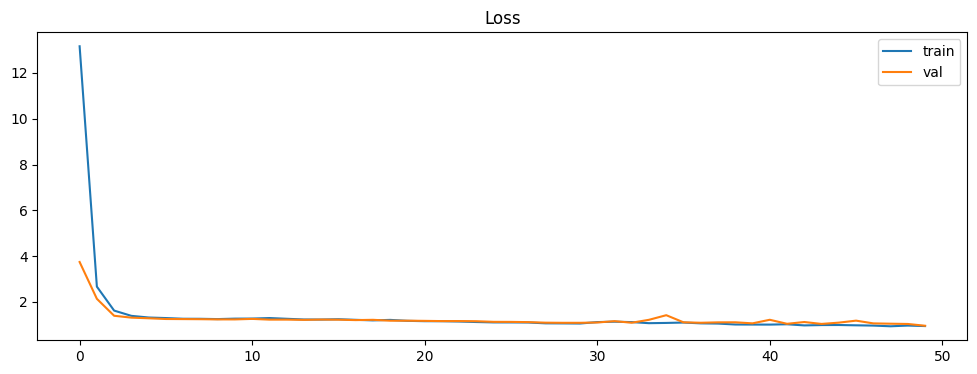

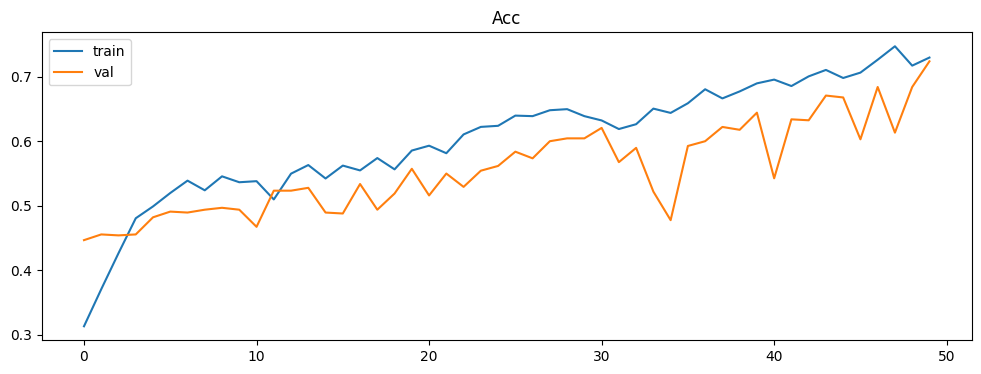

In [63]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(range(len(train_loss_list)), train_loss_list)
plt.plot(range(len(val_loss_list)), val_loss_list)
plt.legend(['train', 'val'])
plt.title('Loss')
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(range(len(train_acc_list)), train_acc_list)
plt.plot(range(len(val_acc_list)), val_acc_list)
plt.legend(['train', 'val'])
plt.title('Acc')
plt.show()

finish training your classifier, next you should use this classifer to predict unlabel images with pseduo label.

## Step2: Use unlabeled data to enhance model performance

In [64]:
# load the trained classifier weights
ckpt = torch.load(SUPERVISED_CKPT, map_location=device)
model.load_state_dict(ckpt)

<All keys matched successfully>

In [65]:
# create a unlabeled data set list, we will use it later
unlabeled_set_list = []
for img in unlabeled_set:
    unlabeled_set_list.append(img)

print("Unlabeled pool size:", len(unlabeled_set_list))

Unlabeled pool size: 1202


### Use the trained classifier to generates pseudo-labels of a dataset.

In [66]:
from tqdm import tqdm
import torch.nn as nn
from torch.utils.data import ConcatDataset
###########################################################
#   You can adjust the threshold to get better result !   #
###########################################################
def get_pseudo_labels(model, threshold=0.9, max_to_keep=200): # 新增包含排序和选取 top_k 的新逻辑

    global unlabeled_set_list
    model.eval()
    imgs_keep = []
    labels_keep = []
    remove_index = []
    soft_max = nn.Softmax(dim=1)
    with torch.no_grad():
        for idx, img in enumerate(tqdm(unlabeled_set_list, desc="Pseudo-labeling", leave=False)):
            img = img.to(device)
            img = img.unsqueeze(0)  # Add batch dimension
            #####################################################################################
            #     TODO:                                                                         #
            #     1. Foward the data, Using torch.no_grad() accelerates the forward process     #
            #     2. obtain the probability distributions by applying softmax on logits         #
            #     3. Filter the data with threshold                                             #
            #     4. Combine the labeled training data with the pseudo-labeled data             #
            #        to construct a new training set. then removed                              #
            #     5. the unlabeled data from unlabeled_set_list                                 #
            #     hint: ConcatDataset                                                           #
            #####################################################################################
            
            # 1. 前向傳播
            outputs = model(img)
            
            # 2. 轉換為機率
            probabilities = soft_max(outputs)
            
            # 3. 找出最大機率值和對應的預測類別
            max_prob, predicted_label = torch.max(probabilities, 1)
            
            # 檢查最大機率是否超過我們設定的信心閾值
            if max_prob.item() > threshold:
                imgs_keep.append(img.squeeze(0).cpu())
                labels_keep.append(predicted_label.item())
                # 5. 記錄這個樣本的索引，稍後將它從 unlabeled_set_list 中移除
                remove_index.append(idx)
            #####################################################################################
            #                           End of your code                                        #
            #####################################################################################

    # Remove processed images from unlabeled list
    for i in reversed(remove_index):
        del unlabeled_set_list[i]

    if imgs_keep:
        # Stack on CPU first, then create TensorDataset
        pseudo_imgs   = torch.stack(imgs_keep, dim=0)                      # [N, C, H, W] on CPU
        pseudo_labels = torch.tensor(labels_keep, dtype=torch.long)        # [N] on CPU
        pseudo_dataset = TensorDataset(pseudo_imgs, pseudo_labels)
        taken = len(pseudo_dataset)
    else:
        pseudo_dataset = TensorDataset(torch.empty(0,3,224,224), torch.empty(0,dtype=torch.long))
        taken = 0

    print(f"Labeled {taken} images this round. Remaining unlabeled: {len(unlabeled_set_list)}")

    # Clear GPU cache to free memory
    torch.cuda.empty_cache()

    return pseudo_dataset, taken

## Redeifine your optimizer if you want

In [67]:
################################################################################
# TODO: Define loss and optmizer functions                                     #
# Try any loss or optimizer function and learning rate to get better result    #
# hint: torch.nn and torch.optim                                               #
################################################################################
n_epochs = 50  #30提升到50
N = 20  # 推迟第一次伪标签生成
initial_lr = 2e-4 # 初始学习率大幅降低
weight_decay_val = 1e-2

criterion = nn.CrossEntropyLoss().to(device)


optimizer = optim.AdamW(model.parameters(), lr=initial_lr, weight_decay=weight_decay_val)


scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=N, T_mult=1, eta_min=1e-6) #  T_mult1改成2
################################################################################
#                               End of your code                               #
################################################################################
criterion = criterion.to(device)

### Train the model

Let's define train function.  

Use the **get_pseudo_labels** function to get the new training set, then construct a new data loader for training.

It will iterate input data 1 epoch and update model with optmizer.  

Finally, calculate mean loss and total accuracy.

In [68]:
import sys
sys.setrecursionlimit(1000000)

#########################################################################################################
#         You can adjust those hyper parameters like epochs or threshold for training                   #
#########################################################################################################
n_epochs = 50 #30提升到50
N = 20  # Update synthesis dataset every N epochs #從10提升到20=
log_interval = 10  # Log every N epochs like supervised training
best_acc = 0.0
SELF_TRAIN_CKPT = 'self_training.pt'

# Initialize with original labeled data
current_train_dataset = train_set
train_loader_ssl = train_loader  # Initialize with original train loader
all_pseudo_datasets = []  # Store all pseudo datasets to accumulate them

for epoch in range(n_epochs):
    #########################################################################################################
    #    TODO:                                                                                              #
    #    In each epoch, relabel the unlabeled dataset for semi-supervised learning.                         #
    #    1. Obtain pseudo-labels for unlabeled data using trained model.(use get_pseudo_labels function)    #
    #    2. Construct a new dataset and a data loader for training.                                         #
    #    You can try different way to use the get_pseudo_label function maybe will get the better result.   #                                  #
    #########################################################################################################
    if epoch > 0 and epoch % N == 0:
        print(f"\n--- [Epoch {epoch+1}] 進入偽標籤產生階段 ---")
     
        # 策略 1: 使用动态阈值
        current_threshold = 0.98 if epoch < (N + 1) else 0.95
        print(f"本轮使用的信心阈值: {current_threshold}")
        
        # 策略 2: 限制每轮加入的数量
        max_new_labels = 200
        print(f"本轮最多加入 {max_new_labels} 个新标签。")
        
        pseudo_dataset, num_taken = get_pseudo_labels(model, threshold=current_threshold, max_to_keep=max_new_labels)

        if num_taken > 0:
            all_pseudo_datasets.append(pseudo_dataset)
            datasets_to_combine = [train_set] + all_pseudo_datasets
            current_train_dataset = ConcatDataset(datasets_to_combine)
            
            train_loader_ssl = DataLoader(
                current_train_dataset,
                shuffle=True,
                **loader_kwargs  
            )
            print(f"成功合併資料集，新的訓練集大小: {len(current_train_dataset)}")

            # 策略 3: 重置 Scheduler
            print("數據集已更新，正在重置學習率排程器...")
            scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2, eta_min=1e-6)
    #########################################################################################################
    #                                          End of your code                                             #
    #########################################################################################################

    try:
        # ---------- Training using the train function from above ----------
        train_acc, train_loss = train(train_loader_ssl, model, criterion, optimizer, epoch=epoch+1, total_epochs=n_epochs)

        # ---------- Validation ----------
        valid_acc, valid_loss = val(val_loader, model, criterion, epoch=epoch+1, total_epochs=n_epochs)

        # Log every log_interval epochs like supervised training
        if (epoch + 1) % log_interval == 0:
            lr = optimizer.param_groups[0]['lr']
            total_pseudo = sum(len(dataset) for dataset in all_pseudo_datasets)
            print('=' * 20, f'Epoch {epoch+1}/{n_epochs}', '=' * 20)
            print('Train Acc: {:.6f} | Train Loss: {:.6f}'.format(train_acc, train_loss))
            print('  Val Acc: {:.6f} |   Val Loss: {:.6f} | LR: {:.6f}'.format(valid_acc, valid_loss, lr))
            print('Dataset Size: {} (original: {}, pseudo: {})'.format(len(current_train_dataset), len(train_set), total_pseudo))

        if valid_acc > best_acc:
            best_acc = valid_acc
            torch.save(model.state_dict(), SELF_TRAIN_CKPT)
            if (epoch + 1) % log_interval != 0:  # Only print if not already logged
                print('[{:03d}/{:03d}] saving model with acc {:.3f}'.format(epoch + 1, n_epochs, best_acc))

    except RuntimeError as e:
        print(f"CUDA error during training epoch {epoch+1}: {e}")
        torch.cuda.empty_cache()

        # Optionally reduce batch size if memory error
        if "out of memory" in str(e).lower():
            new_batch_size = max(batch_size // 2, 1)
            loader_kwargs_reduced = loader_kwargs.copy()
            loader_kwargs_reduced['batch_size'] = new_batch_size

            train_loader_ssl = DataLoader(
                current_train_dataset,
                shuffle=True,
                **loader_kwargs_reduced
            )
    scheduler.step()
#########################################################################################################
#                               End of your code                                                        #
#########################################################################################################

[001/050] saving model with acc 0.690


[003/050] saving model with acc 0.705


[005/050] saving model with acc 0.720


[007/050] saving model with acc 0.727


==================== Epoch 10/50 ====================
Train Acc: 0.779167 | Train Loss: 0.563362
  Val Acc: 0.719764 |   Val Loss: 0.771793 | LR: 0.000116
Dataset Size: 1200 (original: 1200, pseudo: 0)


...

==================== Epoch 30/50 ====================
Train Acc: 0.855830 | Train Loss: 0.465395
  Val Acc: 0.730088 |   Val Loss: 0.796275 | LR: 0.000006
Dataset Size: 1415 (original: 1200, pseudo: 215)


==================== Epoch 40/50 ====================
Train Acc: 0.835336 | Train Loss: 0.449386
  Val Acc: 0.699115 |   Val Loss: 0.836866 | LR: 0.000116
Dataset Size: 1415 (original: 1200, pseudo: 215)

--- [Epoch 41] 進入偽標籤產生階段 ---
本轮使用的信心阈值: 0.95
本轮最多加入 200 个新标签。


Labeled 232 images this round. Remaining unlabeled: 755
成功合併資料集，新的訓練集大小: 1647
數據集已更新，正在重置學習率排程器...


[044/050] saving model with acc 0.749


==================== Epoch 50/50 ====================
Train Acc: 0.890103 | Train Loss: 0.319695
  Val Acc: 0.737463 |   Val Loss: 0.796910 | LR: 0.000006
Dataset Size: 1647 (original: 1200, pseudo: 447)


### Predict Result

Predict the labesl based on testing set. Upload to [Kaggle](https://www.kaggle.com/t/a611e0096e5943cc99a1c0545be28c3c).

**How to upload**

1. Click the folder icon in the left hand side of Colab.
2. Right click "result.csv". Select "Download"
3. To kaggle. Click "Submit Predictions"
4. Upload the result.csv
5. System will automaticlaly calculate the accuracy of 50% dataset and publish this result to leaderboard.

In [69]:
# if you wanna load previous best model
ckpt = torch.load('self_training.pt', map_location=device)
model.load_state_dict(ckpt)

<All keys matched successfully>

In [70]:
test_set = FlowerData(data_folder, split='test', mode='test', transform=transforms_test)
test_loader = DataLoader(
    test_set,
    batch_size=batch_size,
    num_workers=num_workers,
    shuffle=False,
    pin_memory=torch.cuda.is_available()
)

In [71]:
def predict(input_data, model):
    model.eval()
    output_list = []
    with torch.no_grad():
        for images in input_data:
            images = images.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            output_list.extend(predicted.to('cpu').numpy().tolist())
    return output_list

In [72]:
pred_indices = predict(test_loader, model)

with open('result.csv', 'w', newline='') as csvFile:
    writer = csv.DictWriter(csvFile, fieldnames=['ID', 'label'])
    writer.writeheader()
    for filename, pred in zip(test_set.paths, pred_indices):
        filename = osp.basename(filename)  # Extract just the filename
        writer.writerow({'ID': filename, 'label': CLASS_NAMES[int(pred)]})

print("Saved predictions to result.csv")

Saved predictions to result.csv
